Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)


### Full Logistic Regression Analysis

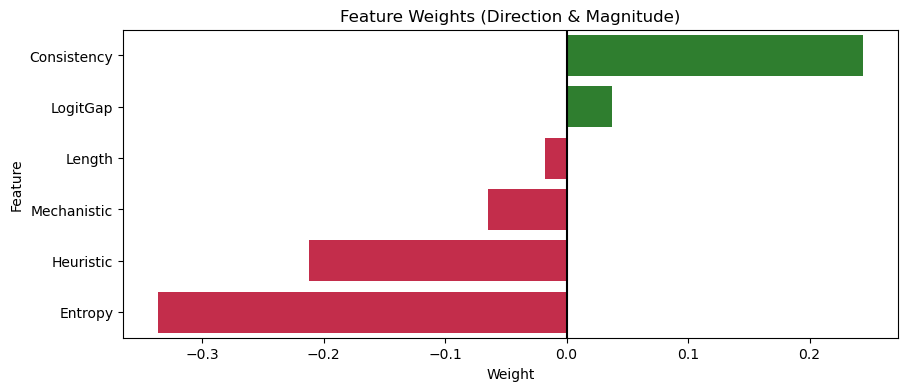

              precision    recall  f1-score   support

           0       0.14      0.56      0.23       164
           1       0.94      0.69      0.79      1772

    accuracy                           0.68      1936
   macro avg       0.54      0.62      0.51      1936
weighted avg       0.88      0.68      0.75      1936



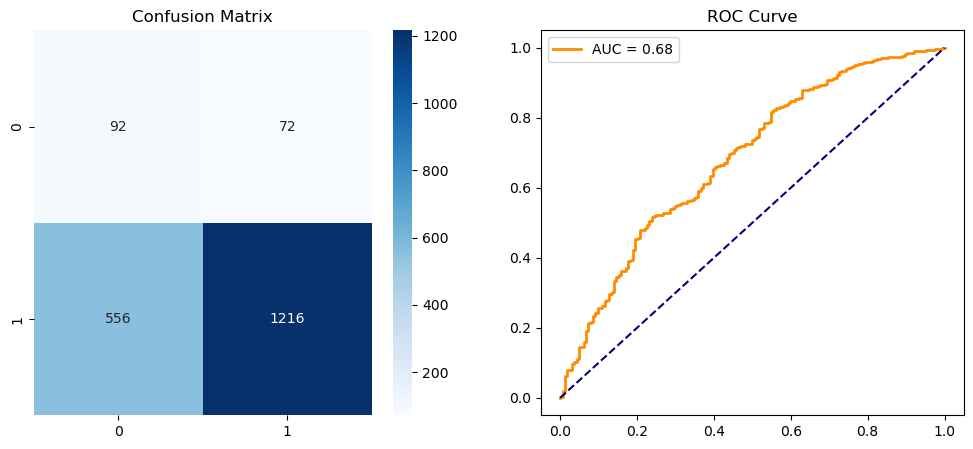

Metric,Shift (SD),Mean,SD,Vis
Entropy,-0.24 SD,0.047,0.014,
LogitGap,+0.13 SD,0.051,0.044,
Heuristic,-0.23 SD,0.437,0.022,
Mechanistic,-0.07 SD,0.965,0.005,
Consistency,-0.14 SD,0.933,0.030,
Length,+1.05 SD,348.577,47.864,
Metric,Shift (SD),Mean,SD,Vis
Entropy,+1.98 SD,0.134,0.027,
LogitGap,-0.12 SD,0.030,0.032,
Heuristic,+0.02 SD,0.447,0.035,


Generating t-SNE...


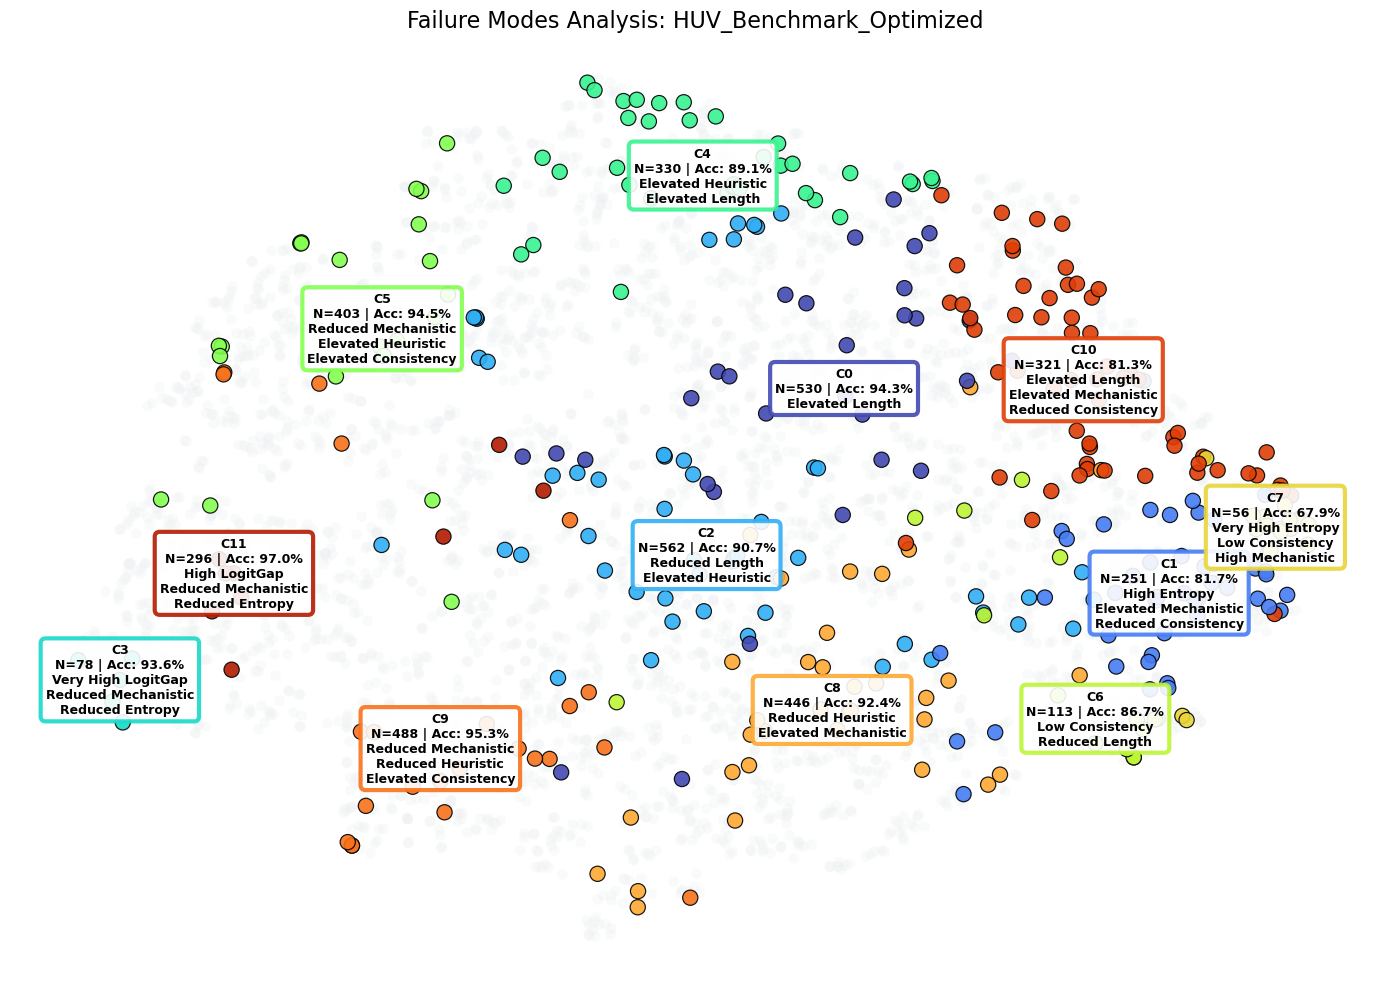

In [1]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

metrics_to_use = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency', 'Length']

logistic_predictor = utils.run_detailed_logistic_regression(df, features=metrics_to_use)

cluster_predictor = utils.run_failure_modes_dashboard(df, exp_info, features=metrics_to_use)

In [2]:
# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion'], _ = logistic_predictor(df)

# 2. Capture Cluster Labels (Index 1)
_, df['Cluster_Label'] = cluster_predictor(df)

# 3. (Optional) Capture Cluster Confidence if needed
df['Cluster_Conf'], _ = cluster_predictor(df)

# Verify
print(df[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion                                      Cluster_Label
0         0.471394  C3\nN=78 | Acc: 93.6%\nVery High LogitGap\nRed...
1         0.493427  C11\nN=296 | Acc: 97.0%\nHigh LogitGap\nReduce...
2         0.523008  C6\nN=113 | Acc: 86.7%\nLow Consistency\nReduc...
3         0.490908  C6\nN=113 | Acc: 86.7%\nLow Consistency\nReduc...
4         0.460939            C0\nN=530 | Acc: 94.3%\nElevated Length


In [3]:
utils.run_comparison_dashboard(df, logistic_predictor, cluster_predictor, metrics_to_use)

,AUROC (↑),ECE (↓),MSE (↓),Status
Model,,,,
Logistic Fusion,0.6783,0.3768,0.2259,
Cluster Baseline,0.6687,0.0000,0.0792,🏆 Winner
Entropy,0.6621,0.0600,0.0845,
LogitGap,0.4038,0.0925,0.0981,
Heuristic,0.4926,0.4041,0.2637,
Mechanistic,0.3630,0.1535,0.1148,
Consistency,0.6152,0.0214,0.0823,
Length,0.5761,0.4274,0.2823,


Model,Mn,Rg
Logistic Fusion,0.50,0.37
Cluster Baseline,0.91,0.00
Entropy,0.84,0.26
LogitGap,0.94,0.23
Heuristic,0.57,0.58
Mechanistic,0.80,0.26
Consistency,0.91,0.18
Length,0.58,0.54
Model,Mn,Rg
Logistic Fusion,0.58,0.31


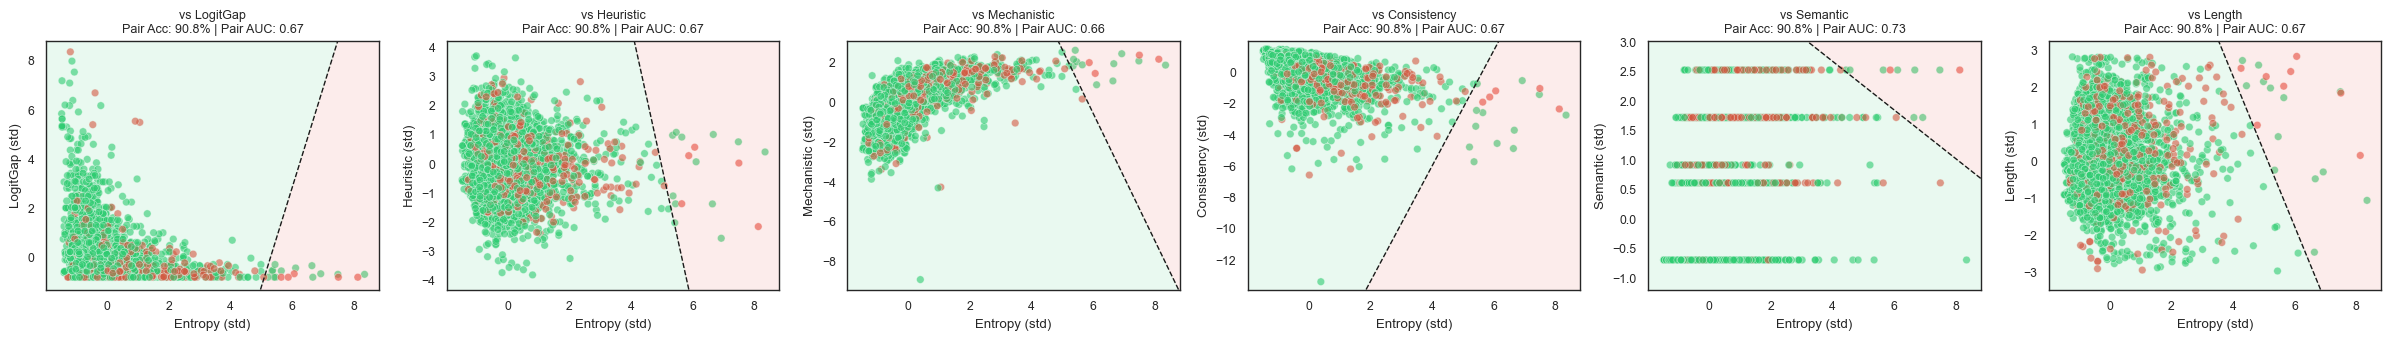

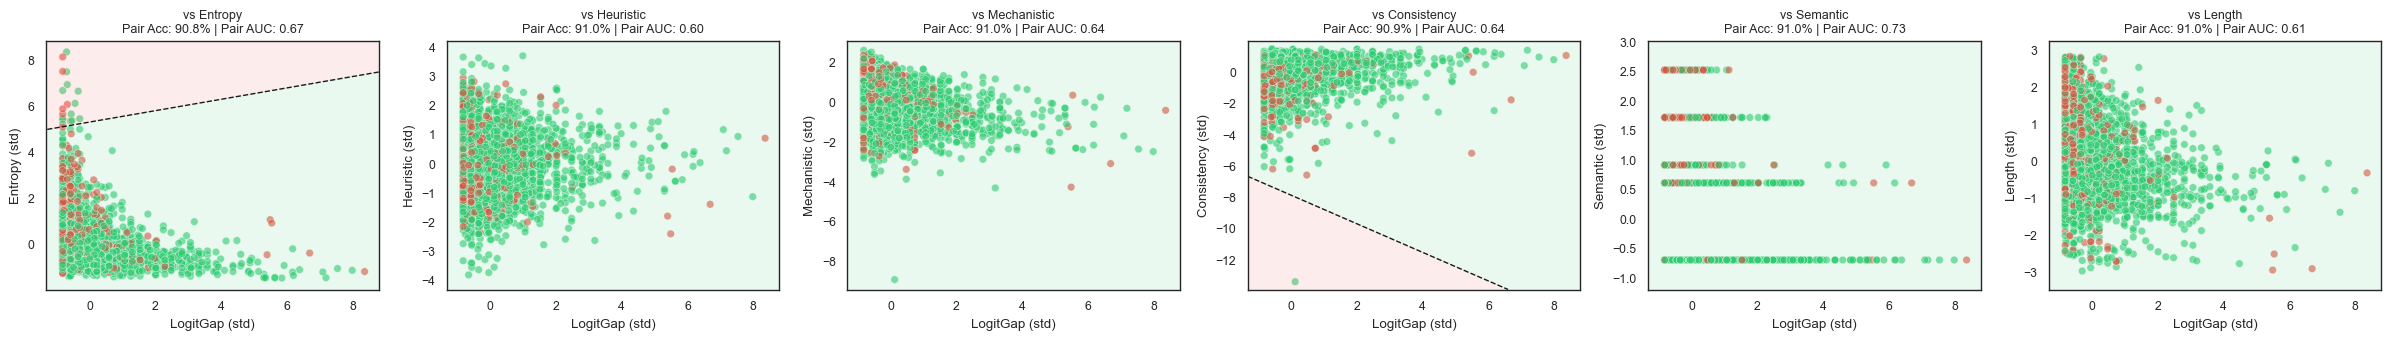

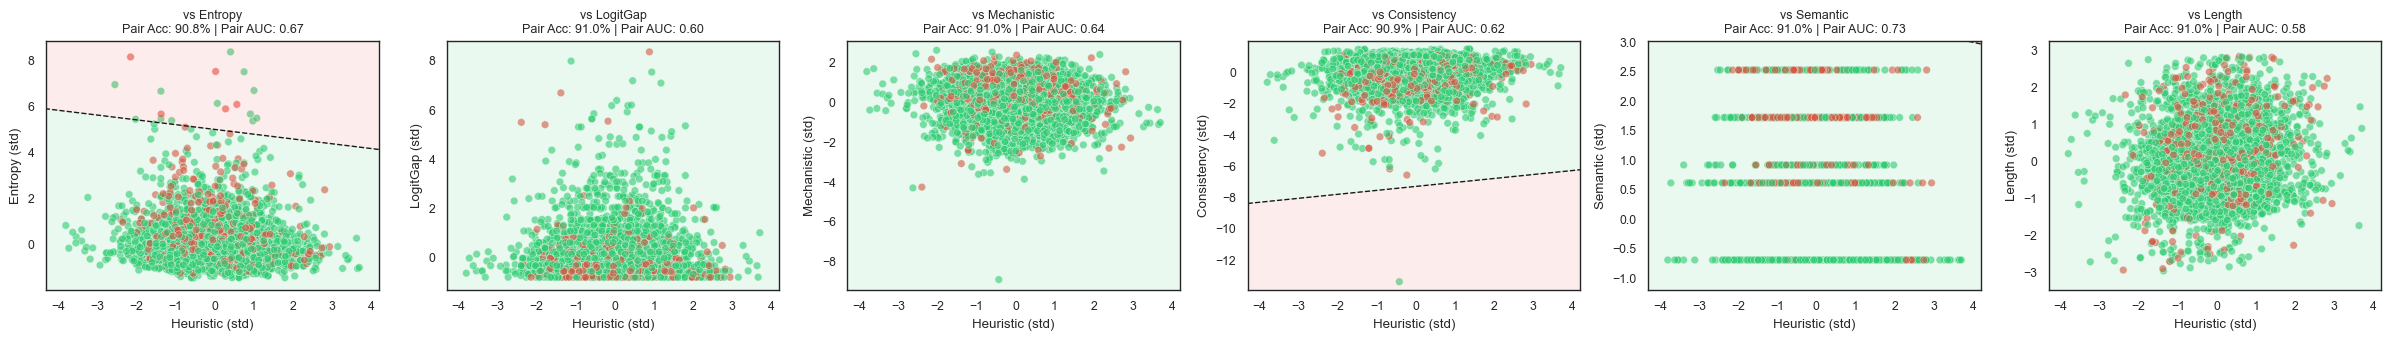

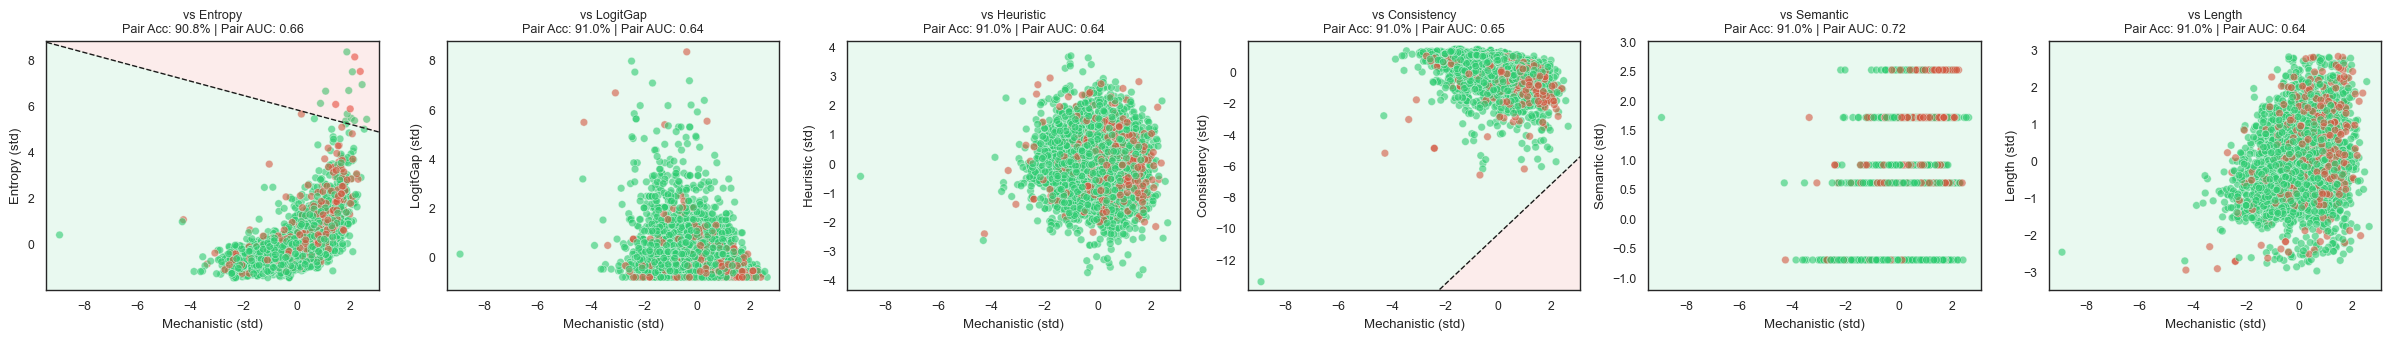

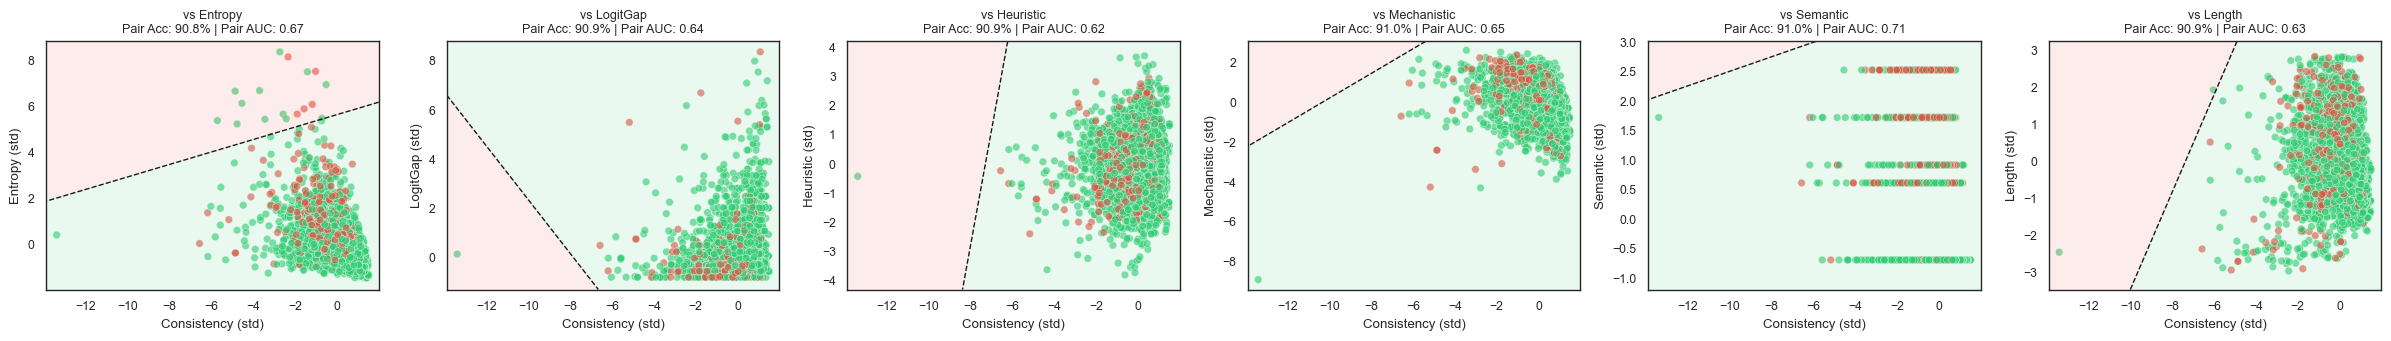

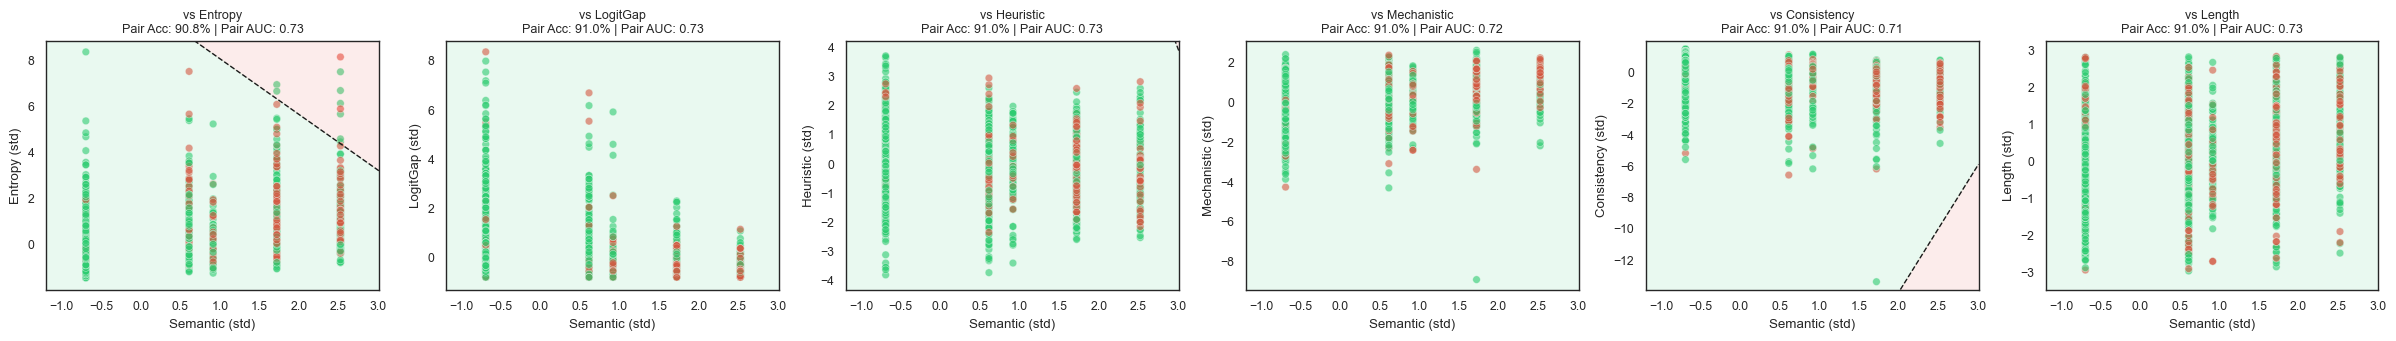

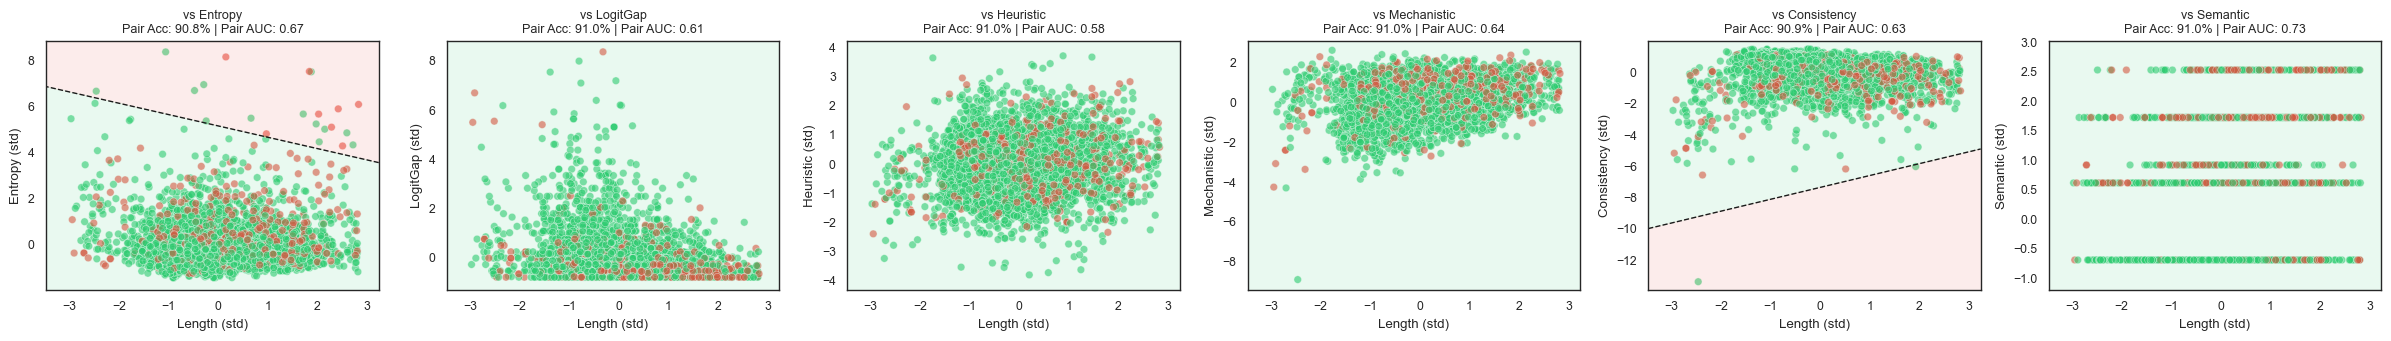

{'Entropy': <analysis_utils.PredictorArtifact at 0x34d192ad0>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x35ee7aa10>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x34b92c2d0>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x33f9b0750>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x34ffffe90>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x35f7635d0>,
 'Length': <analysis_utils.PredictorArtifact at 0x35f73bb90>}

In [4]:
utils.run_full_analysis(df,metrics)

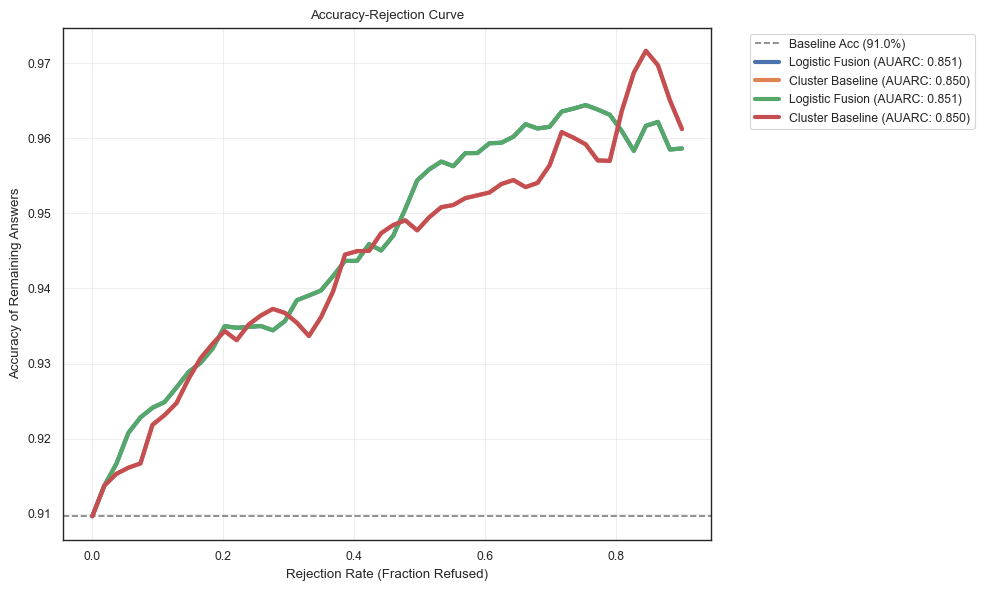

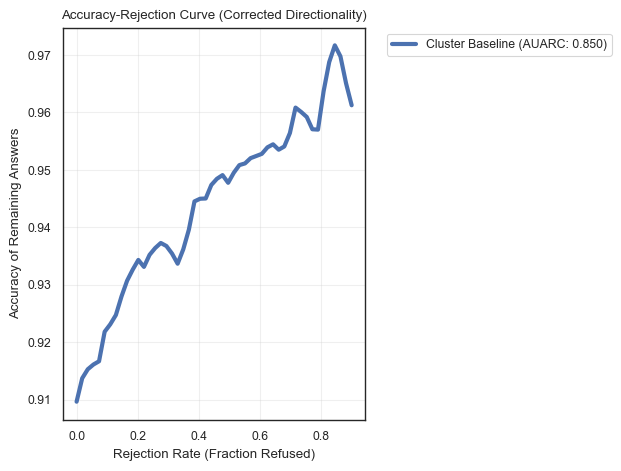

In [5]:
# 1. Convert Text Labels to Numerical Scores (Cluster Accuracy)
# This creates a baseline: "My confidence is the average accuracy of this cluster"
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

# 2. Update the list to use the Numerical column
metrics_to_plot = ['Logistic Fusion', 'Cluster Baseline'] 

# 3. Plot
utils.plot_auarc_analysis(df, metrics_to_plot)

In [6]:
def analyze_outlier_clusters(df):
    from IPython.display import display, HTML
    import pandas as pd
    
    # --- 0. PRE-FILTERING ---
    # Filter out generations longer than 500 tokens
    initial_len = len(df)
    df = df[df['Length'] <= 500].copy()
    filtered_len = len(df)
    
    if initial_len != filtered_len:
        print(f"ℹ️ Filtered {initial_len - filtered_len} rows with Length > 500 (New Size: {filtered_len})")

    # --- CONFIGURATION ---
    # 1. Low Entropy (High Confidence) + Low Mechanistic (High Confidence)
    mask_a = (df['Entropy_Z'] < -0.5) & (df['Mechanistic_Z'] < -0.5) 
    
    # 2. High Entropy (Low Confidence) + High Mechanistic (Low Confidence)
    mask_b = (df['Entropy_Z'] > 0.5) & (df['Mechanistic_Z'] > 0.5)
    
    # 3. Define metrics to display stats for
    metrics_to_show = ['LogitGap', 'Heuristic', 'Consistency', 'Length', 'Semantic']
    
    groups = [
        ("Group A: High Confidence (Low Ent + Low Mech)", mask_a, "#27ae60"), # Green
        ("Group B: High Uncertainty (High Ent + High Mech)", mask_b, "#e74c3c")  # Red
    ]

    # --- HTML STYLING ---
    css = """
    <style>
        .out-box { border: 1px solid #ddd; border-radius: 8px; margin-bottom: 30px; overflow: hidden; font-family: 'Segoe UI', sans-serif; }
        .out-head { padding: 10px 15px; color: white; font-weight: bold; display: flex; justify-content: space-between; }
        .out-stats { padding: 15px; background: #f9f9f9; border-bottom: 1px solid #eee; display: grid; grid-template-columns: repeat(auto-fit, minmax(100px, 1fr)); gap: 10px; text-align: center; }
        .out-stat-item { background: white; padding: 8px; border-radius: 4px; border: 1px solid #eee; box-shadow: 0 1px 2px rgba(0,0,0,0.05); }
        .out-stat-val { font-weight: bold; font-size: 1.1em; color: #2c3e50; }
        .out-stat-lbl { font-size: 0.75em; color: #7f8c8d; text-transform: uppercase; letter-spacing: 0.5px; }
        .ex-row { padding: 10px 15px; border-bottom: 1px solid #eee; font-size: 0.9em; }
        .ex-meta { display: flex; gap: 10px; margin-bottom: 4px; font-size: 0.8em; color: #666; font-family: monospace; }
        .tag { padding: 2px 5px; border-radius: 3px; color: white; font-weight: bold; font-size: 0.8em;}
        .pass { background: #27ae60; } .fail { background: #c0392b; }
    </style>
    """
    display(HTML(css))

    for title, mask, color in groups:
        sub = df[mask].copy()
        n = len(sub)
        
        if n == 0:
            display(HTML(f"<div class='out-box'><div class='out-head' style='background:{color}'>{title} (N=0)</div><div style='padding:15px'>No samples found.</div></div>"))
            continue

        acc = sub['Correct'].mean()
        
        # --- 1. DYNAMIC STATISTICS ---
        stats_html = f"""
        <div class='out-stat-item'><div class='out-stat-val'>{n}</div><div class='out-stat-lbl'>Count</div></div>
        <div class='out-stat-item'><div class='out-stat-val'>{acc:.1%}</div><div class='out-stat-lbl'>Accuracy</div></div>
        """
        
        for m in metrics_to_show:
            if m in sub.columns:
                # Prioritize Z-score if available
                col = f"{m}_Z" if f"{m}_Z" in sub.columns else m
                val = sub[col].mean()
                disp_val = f"{val:.2f}"
                stats_html += f"<div class='out-stat-item'><div class='out-stat-val'>{disp_val}</div><div class='out-stat-lbl'>Avg {m}</div></div>"

        # --- 2. EXAMPLES (Top 10) ---
        examples_html = ""
        # Sort by Entropy to see extreme cases
        for i, row in sub.sort_values('Entropy_Z', ascending=False).head(10).iterrows():
            status = "<span class='tag pass'>PASS</span>" if row['Correct'] else "<span class='tag fail'>FAIL</span>"
            q_text = row.get('question_text', 'N/A')
            ans_text = str(row.get('full_trace_text', ''))[:]
            
            meta = f"Ent: {row.get('Entropy_Z', 0):.2f} | Mech: {row.get('Mechanistic_Z', 0):.2f}"
            
            examples_html += f"""
            <div class='ex-row'>
                <div class='ex-meta'>{status} {meta}</div>
                <div style='font-weight:bold; margin-bottom:2px; color:#2c3e50'>Q: {q_text}</div>
                <div style='color:#555; font-style:italic'>A: {ans_text}</div>
            </div>
            """

        # --- ASSEMBLE ---
        html = f"""
        <div class='out-box'>
            <div class='out-head' style='background:{color}'>
                <span>{title}</span>
                <span>Size: {n} ({n/len(df):.1%})</span>
            </div>
            <div class='out-stats'>{stats_html}</div>
            <div style='max-height:400px; overflow-y:auto'>{examples_html}</div>
        </div>
        """
        display(HTML(html))

# --- RUN IT ---
analyze_outlier_clusters(df)

In [7]:
def analyze_outlier_clusters(df):
    from IPython.display import display, HTML
    import pandas as pd
    
    # --- 0. PRE-FILTERING ---
    # Filter out generations longer than 500 tokens
    initial_len = len(df)
    df = df[df['Length'] <= 500].copy()
    filtered_len = len(df)
    
    if initial_len != filtered_len:
        print(f"ℹ️ Filtered {initial_len - filtered_len} rows with Length > 500 (New Size: {filtered_len})")

    # --- CONFIGURATION ---
    # 1. Low Entropy (High Confidence) + Low Mechanistic (High Confidence)
    mask_a = (df['Entropy_Z'] < -0.5) & (df['Mechanistic_Z'] < -0.5) 
    
    # 2. High Entropy (Low Confidence) + High Mechanistic (Low Confidence)
    mask_b = (df['Entropy_Z'] > 0.5) & (df['Mechanistic_Z'] > 0.5)
    
    # 3. Define metrics to display stats for
    metrics_to_show = ['LogitGap', 'Heuristic', 'Consistency', 'Length', 'Semantic']
    
    groups = [
        ("Group A: High Confidence (Low Ent + Low Mech)", mask_a, "#27ae60"), # Green
        ("Group B: High Uncertainty (High Ent + High Mech)", mask_b, "#e74c3c")  # Red
    ]

    # --- HTML STYLING ---
    css = """
    <style>
        .out-box { border: 1px solid #ddd; border-radius: 8px; margin-bottom: 30px; overflow: hidden; font-family: 'Segoe UI', sans-serif; }
        .out-head { padding: 10px 15px; color: white; font-weight: bold; display: flex; justify-content: space-between; }
        .out-stats { padding: 15px; background: #f9f9f9; border-bottom: 1px solid #eee; display: grid; grid-template-columns: repeat(auto-fit, minmax(100px, 1fr)); gap: 10px; text-align: center; }
        .out-stat-item { background: white; padding: 8px; border-radius: 4px; border: 1px solid #eee; box-shadow: 0 1px 2px rgba(0,0,0,0.05); }
        .out-stat-val { font-weight: bold; font-size: 1.1em; color: #2c3e50; }
        .out-stat-lbl { font-size: 0.75em; color: #7f8c8d; text-transform: uppercase; letter-spacing: 0.5px; }
        .ex-row { padding: 10px 15px; border-bottom: 1px solid #eee; font-size: 0.9em; }
        .ex-meta { display: flex; gap: 10px; margin-bottom: 4px; font-size: 0.8em; color: #666; font-family: monospace; }
        .tag { padding: 2px 5px; border-radius: 3px; color: white; font-weight: bold; font-size: 0.8em;}
        .pass { background: #27ae60; } .fail { background: #c0392b; }
    </style>
    """
    display(HTML(css))

    for title, mask, color in groups:
        sub = df[mask].copy()
        n = len(sub)
        
        if n == 0:
            display(HTML(f"<div class='out-box'><div class='out-head' style='background:{color}'>{title} (N=0)</div><div style='padding:15px'>No samples found.</div></div>"))
            continue

        acc = sub['Correct'].mean()
        
        # --- 1. DYNAMIC STATISTICS ---
        stats_html = f"""
        <div class='out-stat-item'><div class='out-stat-val'>{n}</div><div class='out-stat-lbl'>Count</div></div>
        <div class='out-stat-item'><div class='out-stat-val'>{acc:.1%}</div><div class='out-stat-lbl'>Accuracy</div></div>
        """
        
        for m in metrics_to_show:
            if m in sub.columns:
                # Prioritize Z-score if available
                col = f"{m}_Z" if f"{m}_Z" in sub.columns else m
                val = sub[col].mean()
                disp_val = f"{val:.2f}"
                stats_html += f"<div class='out-stat-item'><div class='out-stat-val'>{disp_val}</div><div class='out-stat-lbl'>Avg {m}</div></div>"

        # --- 2. EXAMPLES (Top 10) ---
        examples_html = ""
        # Sort by Entropy to see extreme cases
        for i, row in sub.sort_values('Entropy_Z', ascending=False).head(10).iterrows():
            status = "<span class='tag pass'>PASS</span>" if row['Correct'] else "<span class='tag fail'>FAIL</span>"
            q_text = row.get('question_text', 'N/A')
            ans_text = str(row.get('full_trace_text', ''))[:]
            
            meta = f"Ent: {row.get('Entropy_Z', 0):.2f} | Mech: {row.get('Mechanistic_Z', 0):.2f}"
            
            examples_html += f"""
            <div class='ex-row'>
                <div class='ex-meta'>{status} {meta}</div>
                <div style='font-weight:bold; margin-bottom:2px; color:#2c3e50'>Q: {q_text}</div>
                <div style='color:#555; font-style:italic'>A: {ans_text}</div>
            </div>
            """

        # --- ASSEMBLE ---
        html = f"""
        <div class='out-box'>
            <div class='out-head' style='background:{color}'>
                <span>{title}</span>
                <span>Size: {n} ({n/len(df):.1%})</span>
            </div>
            <div class='out-stats'>{stats_html}</div>
            <div style='max-height:400px; overflow-y:auto'>{examples_html}</div>
        </div>
        """
        display(HTML(html))

# --- RUN IT ---
analyze_outlier_clusters(df)

Analyzing 986 questions with multiple answers...


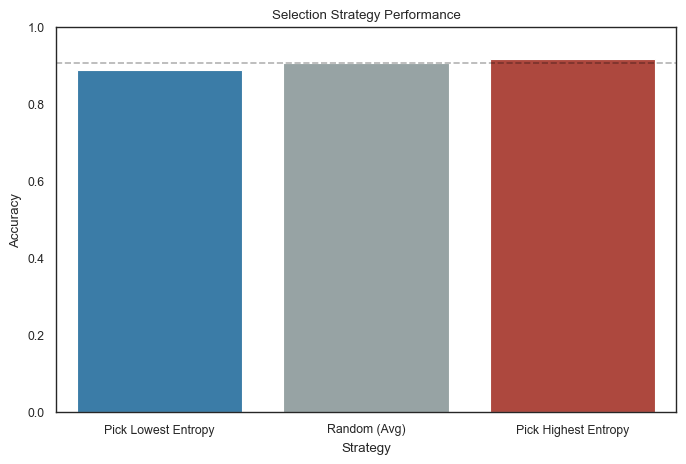

In [8]:
def analyze_intra_question_entropy(df):
    """
    Analyzes if lower entropy answers are more accurate WITHIN the same question group.
    Requires multiple samples per question.
    """
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from IPython.display import display, HTML

    # 1. Identify Grouping Column
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    
    # 2. Filter for questions with multiple samples (and variance in Entropy)
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped['Entropy'].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers to compare.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    # 3. Extract Best/Worst/Avg stats per question
    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Min and Max Entropy
        id_min = group['Entropy'].idxmin()
        id_max = group['Entropy'].idxmax()
        
        # Skip if flat entropy (min == max)
        if group.loc[id_min, 'Entropy'] == group.loc[id_max, 'Entropy']:
            continue

        results.append({
            'Question': q_id,
            'Min_Ent_Correct': group.loc[id_min, 'Correct'],
            'Max_Ent_Correct': group.loc[id_max, 'Correct'],
            'Avg_Correct': group['Correct'].mean(),
            'Ent_Spread': group.loc[id_max, 'Entropy'] - group.loc[id_min, 'Entropy']
        })

    if not results:
        print("⚠️ No variance in entropy found within groups.")
        return

    res_df = pd.DataFrame(results)

    # 4. Calculate Final Accuracies
    acc_min = res_df['Min_Ent_Correct'].mean()
    acc_max = res_df['Max_Ent_Correct'].mean()
    acc_avg = res_df['Avg_Correct'].mean()
    
    # 5. Display HTML Summary
    delta = acc_min - acc_avg
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px'>
        <h3 style='margin-top:0'>Intra-Question Analysis (N={len(res_df)})</h3>
        <p><i>Does picking the lowest entropy answer beat random selection?</i></p>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#2c3e50'>{acc_avg:.1%}</div>
                <div style='color:#7f8c8d'>Random (Baseline)</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#2980b9'>{acc_min:.1%}</div>
                <div style='color:#7f8c8d'>Lowest Entropy (Best)</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_max:.1%}</div>
                <div style='color:#7f8c8d'>Highest Entropy (Worst)</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}'>
            Gain: {delta:+.1%} over baseline
        </div>
    </div>
    """
    display(HTML(html))

    # 6. Plot
    plt.figure(figsize=(8, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Lowest Entropy', 'Random (Avg)', 'Pick Highest Entropy'],
        'Accuracy': [acc_min, acc_avg, acc_max]
    })
    
    sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#2980b9', '#95a5a6', '#c0392b'])
    plt.ylim(0, 1.0)
    plt.axhline(acc_avg, color='black', linestyle='--', alpha=0.3)
    plt.title("Selection Strategy Performance")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN ---
analyze_intra_question_entropy(df)

Training Logistic Fusion on subset: ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']...
Feature Weights (Positive = Predicts Correct):
    Feature    Weight
    Entropy  0.568550
     Length  0.169377
Mechanistic  0.017595
   LogitGap -0.020512
  Heuristic -0.113131

Analyzing 986 questions with multiple answers...


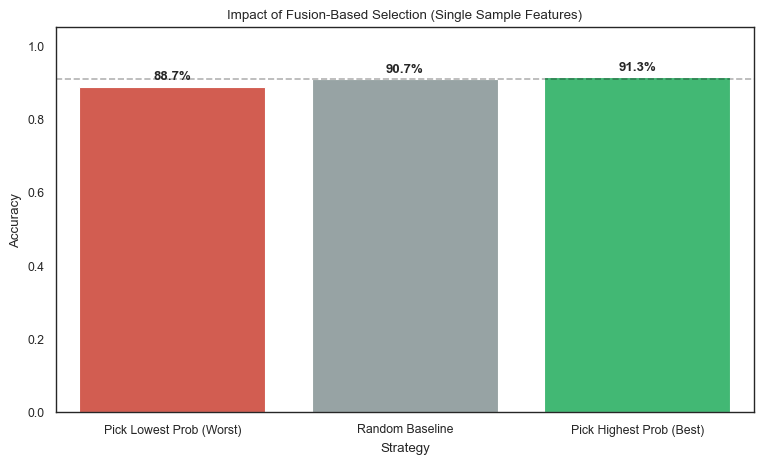

In [9]:
def analyze_intra_question_fusion_subset(df):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. TRAIN NEW FUSION MODEL (Subset Features Only) ---
    # We exclude 'Consistency' and 'Semantic' as requested
    subset_features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    
    print(f"Training Logistic Fusion on subset: {subset_features}...")
    
    # Prepare Data
    # Use fillna(0) to handle any missing values safely
    X = df[subset_features].fillna(0)
    y = df['Correct']
    
    # Scale & Fit
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = LogisticRegression(class_weight='balanced', random_state=42)
    clf.fit(X_scaled, y)
    
    # Generate Probabilities (Probability of being Correct)
    prob_col = 'Fusion_Prob_Subset'
    df[prob_col] = clf.predict_proba(X_scaled)[:, 1]
    
    # Show weights to see what drives the single-sample model
    coef_df = pd.DataFrame({'Feature': subset_features, 'Weight': clf.coef_[0]})
    coef_df = coef_df.sort_values('Weight', ascending=False)
    print("Feature Weights (Positive = Predicts Correct):")
    print(coef_df.to_string(index=False))

    # --- 2. INTRA-QUESTION ANALYSIS ---
    
    # Identify Grouping Column
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    
    # Filter for questions with multiple samples
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"\nAnalyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Best (Max Prob) and Worst (Min Prob) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if model can't distinguish (probabilities are identical)
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Did we pick the right one?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Did we avoid the wrong one?
            'Random_Baseline': group['Correct'].mean(),               # Expected acc if picking randomly
            'Prob_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ No variance in probabilities found within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 3. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Logistic Fusion Selection (Single-Sample Only)</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer with highest <b>Fusion_Prob_Subset</b> per question.<br>
            (Ignoring Consistency/Semantic metrics)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#2980b9'>{acc_best:.1%}</div>
                <div style='color:#2980b9; font-weight:bold; font-size:0.8em'>Fusion Selection</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Prob</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Lowest Prob (Worst)', 'Random Baseline', 'Pick Highest Prob (Best)'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#2ecc71'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    # Add labels
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Fusion-Based Selection (Single Sample Features)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_fusion_subset(df)

Training Logistic Fusion on subset: ['Entropy', 'Heuristic', 'Mechanistic']...
Feature Weights (Positive = Predicts Correct):
    Feature    Weight
    Entropy  0.529855
Mechanistic -0.071036
  Heuristic -0.131234

Analyzing 986 questions with multiple answers...


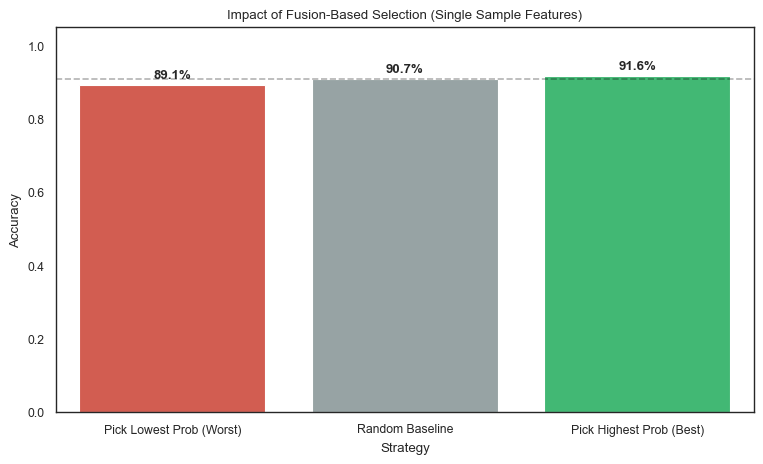

In [10]:
def analyze_intra_question_fusion_subset(df):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. TRAIN NEW FUSION MODEL (Subset Features Only) ---
    # We exclude 'Consistency' and 'Semantic' as requested
    subset_features = [ "Entropy", "Heuristic", "Mechanistic"]#, 'Heuristic', 'Mechanistic']
    
    print(f"Training Logistic Fusion on subset: {subset_features}...")
    
    # Prepare Data
    # Use fillna(0) to handle any missing values safely
    X = df[subset_features].fillna(0)
    y = df['Correct']
    
    # Scale & Fit
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = LogisticRegression(class_weight='balanced', random_state=42)
    clf.fit(X_scaled, y)
    
    # Generate Probabilities (Probability of being Correct)
    prob_col = 'Fusion_Prob_Subset'
    df[prob_col] = clf.predict_proba(X_scaled)[:, 1]
    
    # Show weights to see what drives the single-sample model
    coef_df = pd.DataFrame({'Feature': subset_features, 'Weight': clf.coef_[0]})
    coef_df = coef_df.sort_values('Weight', ascending=False)
    print("Feature Weights (Positive = Predicts Correct):")
    print(coef_df.to_string(index=False))

    # --- 2. INTRA-QUESTION ANALYSIS ---
    
    # Identify Grouping Column
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    
    # Filter for questions with multiple samples
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"\nAnalyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Best (Max Prob) and Worst (Min Prob) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if model can't distinguish (probabilities are identical)
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Did we pick the right one?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Did we avoid the wrong one?
            'Random_Baseline': group['Correct'].mean(),               # Expected acc if picking randomly
            'Prob_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ No variance in probabilities found within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 3. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Logistic Fusion Selection (Single-Sample Only)</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer with highest <b>Fusion_Prob_Subset</b> per question.<br>
            (Ignoring Consistency/Semantic metrics)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#2980b9'>{acc_best:.1%}</div>
                <div style='color:#2980b9; font-weight:bold; font-size:0.8em'>Fusion Selection</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Prob</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Lowest Prob (Worst)', 'Random Baseline', 'Pick Highest Prob (Best)'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#2ecc71'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    # Add labels
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Fusion-Based Selection (Single Sample Features)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_fusion_subset(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']...
Identified 12 clusters. Safety Scores (Accuracy) range: 68.3% - 97.4%
Analyzing 986 questions with multiple answers...


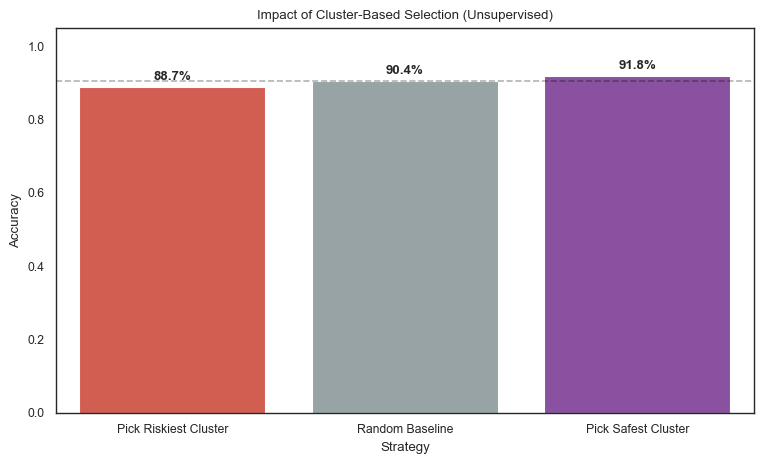

In [11]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 64.0% - 96.1%
Analyzing 986 questions with multiple answers...


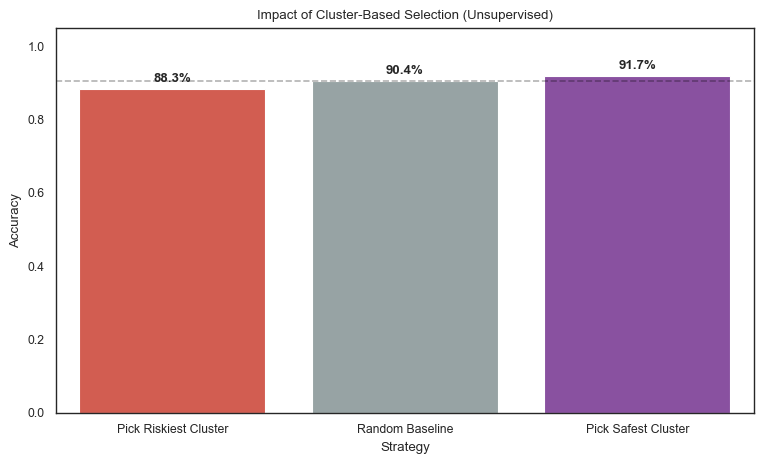

In [12]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)

🔍 Analyzing all 31 feature subsets...


,Feature,Impact,Verdict
4,Length,-0.70%,TOSS
2,Heuristic,-0.22%,TOSS
1,LogitGap,0.06%,BORDERLINE
3,Mechanistic,0.74%,BORDERLINE
0,Entropy,2.02%,KEEP


,Size,Features,Acc_Best,Acc_Worst,Gap
0,2,"Entropy, LogitGap",91.5%,88.3%,3.1%
1,1,Entropy,91.7%,88.7%,2.9%
2,3,"Entropy, LogitGap, Heuristic",91.7%,88.7%,2.9%
3,2,"Entropy, Heuristic",91.7%,88.9%,2.7%
4,4,"Entropy, LogitGap, Heuristic, Length",91.3%,88.6%,2.6%


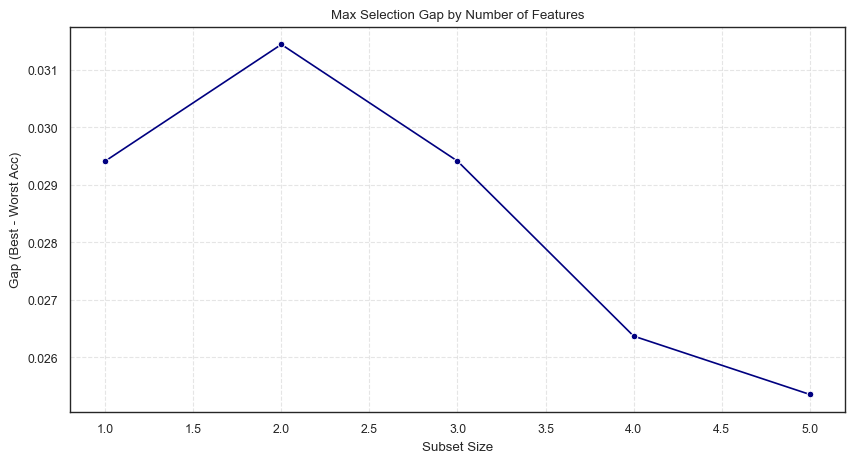

In [13]:
def analyze_feature_redundancy(df):
    import itertools
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from IPython.display import display, HTML
    
    # 1. Setup
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    results = []
    
    print(f"🔍 Analyzing all {2**len(features) - 1} feature subsets...")
    
    # Pre-scale to speed up the loop
    X_raw = df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=features, index=df.index)
    y = df['Correct']
    
    # Pre-filter for evaluation (Questions with multiple answers)
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    eval_mask = grouped[group_col].transform('count') > 1
    eval_df_base = df.loc[eval_mask, [group_col, 'Correct']].copy()
    
    if len(eval_df_base) == 0:
        print("⚠️ No multi-answer questions found to analyze.")
        return

    # 2. Brute-Force Search
    for r in range(1, len(features) + 1):
        for subset in itertools.combinations(features, r):
            cols = list(subset)
            
            # Train Fusion Model
            clf = LogisticRegression(class_weight='balanced', random_state=42)
            clf.fit(X_scaled[cols], y)
            
            # Predict
            probs = clf.predict_proba(X_scaled[cols])[:, 1]
            prob_series = pd.Series(probs, index=df.index)
            
            # Evaluate Selection Gap
            current_eval = eval_df_base.copy()
            current_eval['probs'] = prob_series[eval_mask]
            
            # Find best/worst per question
            g = current_eval.groupby(group_col)['probs']
            best_idx = g.idxmax()
            worst_idx = g.idxmin()
            
            # Only count questions where model actually distinguishes (Prob Best != Prob Worst)
            distinct_mask = current_eval.loc[best_idx, 'probs'].values != current_eval.loc[worst_idx, 'probs'].values
            
            valid_best = best_idx[distinct_mask]
            valid_worst = worst_idx[distinct_mask]
            
            if len(valid_best) > 0:
                acc_best = current_eval.loc[valid_best, 'Correct'].mean()
                acc_worst = current_eval.loc[valid_worst, 'Correct'].mean()
                gap = acc_best - acc_worst
                
                results.append({
                    'Size': len(cols),
                    'Features': ", ".join(cols),
                    'Acc_Best': acc_best,
                    'Acc_Worst': acc_worst,
                    'Gap': gap
                })

    # 3. Process Results
    res_df = pd.DataFrame(results).sort_values('Gap', ascending=False).reset_index(drop=True)
    
    # 4. Dispensability Analysis (Impact Score)
    # How much does the Gap drop when we REMOVE this feature?
    feature_impact = []
    for f in features:
        # Average Gap of subsets WITH feature f
        with_f = res_df[res_df['Features'].str.contains(f)]['Gap'].mean()
        # Average Gap of subsets WITHOUT feature f
        without_f = res_df[~res_df['Features'].str.contains(f)]['Gap'].mean()
        
        impact = with_f - without_f
        feature_impact.append({
            'Feature': f, 
            'Impact': impact,
            'Verdict': 'KEEP' if impact > 0.02 else ('BORDERLINE' if impact > 0 else 'TOSS')
        })
    
    impact_df = pd.DataFrame(feature_impact).sort_values('Impact', ascending=True)

    # --- DISPLAYS ---
    
    # A. Variable Impact Table
    html_impact = "<h3>🗑️ Variable Dispensability (Sorted by 'Freest to Throw Out')</h3>"
    html_impact += "<p><i>Low or Negative Impact = Removing this variable doesn't hurt (or helps).</i></p>"
    html_impact += impact_df.style.bar(subset=['Impact'], align='mid', color=['#e74c3c', '#27ae60'])\
        .format("{:.2%}", subset=['Impact'])\
        .to_html()
    display(HTML(html_impact))
    
    # B. Top Subsets Table
    html_top = "<h3>🏆 Top 5 Feature Combinations</h3>"
    html_top += res_df.head(5).style.background_gradient(subset=['Gap'], cmap='Greens')\
        .format("{:.1%}", subset=['Acc_Best', 'Acc_Worst', 'Gap'])\
        .to_html()
    display(HTML(html_top))

    # C. Complexity vs Performance Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=res_df, x='Size', y='Gap', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Max Selection Gap by Number of Features")
    plt.ylabel("Gap (Best - Worst Acc)")
    plt.xlabel("Subset Size")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- EXECUTE ---
analyze_feature_redundancy(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 64.0% - 96.1%
Analyzing 986 questions with multiple answers...


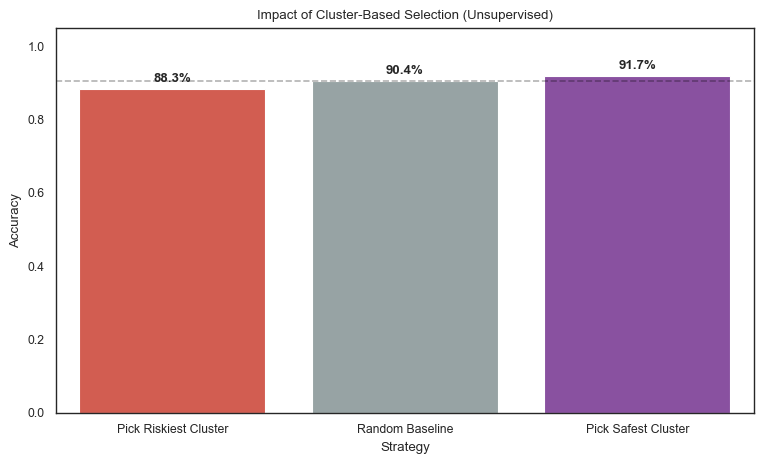

In [14]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)